# Part 3: Sales Forecasting — Advanced Model
**Team:** GenCore | **Lead:** Trịnh Hoàng Tú

**Objective:** Predict daily `Revenue` and `COGS` for 2023-01-01 → 2024-07-01.

**Strategy:**
1. Baseline: Seasonal profile + YoY growth (see `baseline.ipynb`)
2. Advanced: XGBoost with time-based + web traffic features

In [1]:
# === Environment Detection & Path Config ===
import os
import sys
import importlib
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

IS_KAGGLE = os.path.exists('/kaggle/input')

if IS_KAGGLE:
    DATA_DIR = None
    for root, dirs, files in os.walk('/kaggle/input'):
        if 'sales.csv' in files:
            DATA_DIR = root + '/'
            break
    if DATA_DIR is None:
        raise FileNotFoundError('Could not find sales.csv under /kaggle/input')
    OUT_DIR = '/kaggle/working/'
else:
    DATA_DIR = '../data/raw/'
    OUT_DIR = '../output/'
    sys.path.append(os.path.abspath('..'))

RANDOM_SEED = 42

from src.preprocessing import preprocess_all
import src.features as features_module
import src.models as models_module

importlib.reload(features_module)
importlib.reload(models_module)

build_features = features_module.build_features
train_and_evaluate = models_module.train_and_evaluate
export_feature_importance = models_module.export_feature_importance
generate_submission = models_module.generate_submission

print(f"Environment: {'Kaggle' if IS_KAGGLE else 'Local'}")
print(f"Data dir:    {DATA_DIR}")
print(f"Out dir:     {OUT_DIR}")

Environment: Local
Data dir:    ../data/raw/
Out dir:     ../output/


## 1 — Data Loading

In [2]:
bundle = preprocess_all(data_path=DATA_DIR)
train_df = bundle['train_df'].copy()

sample_sub = pd.read_csv(os.path.join(DATA_DIR, 'sample_submission.csv'), parse_dates=['Date'])
forecast_base = sample_sub[['Date']].rename(columns={'Date': 'order_date'})

print(f"Train daily: {train_df.shape} | {train_df['order_date'].min().date()} -> {train_df['order_date'].max().date()}")
print(f"Forecast horizon (from sample_submission): {forecast_base.shape}")
print(f"Meta: {bundle['meta']}")
train_df.head()

Train daily: (3833, 19) | 2012-07-04 -> 2022-12-31
Forecast horizon (from sample_submission): (548, 1)
Meta: {'transaction_rows': 714669, 'train_rows': 3833, 'forecast_rows': 30, 'date_min': '2012-07-04', 'date_max': '2022-12-31', 'features_for_model': ['orders', 'items', 'avg_discount', 'returned_items', 'sessions', 'unique_visitors', 'page_views', 'bounce_rate', 'avg_session_duration_sec', 'year', 'month', 'day', 'day_of_week', 'week_of_year', 'quarter', 'is_weekend']}


,order_date,Revenue,COGS,orders,items,avg_discount,returned_items,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,year,month,day,day_of_week,week_of_year,quarter,is_weekend
0,2012-07-04,4952480.930,3.982991e+06,162,777,0.0,26.0,20813.0,15631.0,90214.5,0.00425,185.35,2012,7,4,2,27,3,0
1,2012-07-05,2694430.540,2.150580e+06,97,428,0.0,15.0,20813.0,15631.0,90214.5,0.00425,185.35,2012,7,5,3,27,3,0
2,2012-07-06,2858414.840,2.517633e+06,93,441,0.0,28.0,20813.0,15631.0,90214.5,0.00425,185.35,2012,7,6,4,27,3,0
3,2012-07-07,2532164.075,2.108247e+06,73,364,0.0,14.0,20813.0,15631.0,90214.5,0.00425,185.35,2012,7,7,5,27,3,1
4,2012-07-08,2224980.070,1.808623e+06,88,394,0.0,21.0,20813.0,15631.0,90214.5,0.00425,185.35,2012,7,8,6,27,3,1


## 2 — Feature Engineering
**Anti-leakage:** We only use time features and web traffic. No future Revenue/COGS.

In [3]:
cutoff_date = forecast_base['order_date'].min() - pd.Timedelta(days=1)

feature_bundle = build_features(
    train_df=train_df,
    forecast_df=forecast_base,
    data_path=DATA_DIR,
    date_col='order_date',
    cutoff_date=cutoff_date,
    target_cols=('Revenue', 'COGS'),
    lags=(7, 14),
    rolling_windows=(7, 14),
)

train_features = feature_bundle['train_features']
forecast_features = feature_bundle['forecast_features']
FEATURE_COLS = feature_bundle['feature_cols']

print(f"Cutoff date (anti-leakage): {cutoff_date.date()}")
print(f"Train features: {train_features.shape}")
print(f"Forecast features: {forecast_features.shape}")
print(f"#Feature cols: {len(FEATURE_COLS)}")
print('Sample features:', FEATURE_COLS[:12])
train_features.head()

Cutoff date (anti-leakage): 2022-12-31
Train features: (3819, 45)
Forecast features: (548, 37)
#Feature cols: 36
Sample features: ['sessions', 'unique_visitors', 'page_views', 'bounce_rate', 'avg_session_duration_sec', 'year', 'month', 'day', 'quarter', 'is_weekend', 'dayofweek', 'dayofyear']


,order_date,Revenue,COGS,orders,items,avg_discount,returned_items,sessions,unique_visitors,page_views,...,reorder_flag,sell_through_rate,Revenue_lag_7,Revenue_lag_14,Revenue_roll_mean_7,Revenue_roll_mean_14,COGS_lag_7,COGS_lag_14,COGS_roll_mean_7,COGS_roll_mean_14
0,2012-07-18,5050412.170,4.072012e+06,225,1085,0.0,46.0,20813.0,15631.0,90214.5,...,0.0,0.243548,5409105.05,4952480.930,4.508680e+06,3.951980e+06,4.338313e+06,3.982991e+06,3.620251e+06,3.195865e+06
1,2012-07-19,6151933.515,5.007271e+06,263,1322,0.0,64.0,20813.0,15631.0,90214.5,...,0.0,0.243548,5640030.05,2694430.540,4.457438e+06,3.958975e+06,4.458811e+06,2.150580e+06,3.582208e+06,3.202224e+06
2,2012-07-20,5098090.940,4.213990e+06,231,1227,0.0,21.0,20813.0,15631.0,90214.5,...,0.0,0.243548,5253358.84,2858414.840,4.530567e+06,4.205940e+06,4.143403e+06,2.517633e+06,3.660559e+06,3.406273e+06
3,2012-07-21,3325730.570,2.746075e+06,171,855,0.0,26.0,20813.0,15631.0,90214.5,...,0.0,0.243548,3644637.28,2532164.075,4.508386e+06,4.365916e+06,3.075465e+06,2.108247e+06,3.670643e+06,3.527441e+06
4,2012-07-22,2993669.420,2.531656e+06,140,714,0.0,20.0,20813.0,15631.0,90214.5,...,0.0,0.243548,3829480.29,2224980.070,4.462828e+06,4.422600e+06,3.154482e+06,1.808623e+06,3.623587e+06,3.573000e+06


In [4]:
X_train = train_features[FEATURE_COLS]
y_rev = train_features['Revenue']
y_cogs = train_features['COGS']

print(f'X_train shape: {X_train.shape}')
print(f'y_rev shape:   {y_rev.shape}')
print(f'y_cogs shape:  {y_cogs.shape}')
print(f'NaN in X_train: {X_train.isna().sum().sum()}')

X_train shape: (3819, 36)
y_rev shape:   (3819,)
y_cogs shape:  (3819,)
NaN in X_train: 0


## 3 — Train XGBoost + LightGBM (Same Features, Same Split)

In [5]:
candidate_model_names = ['xgboost', 'lightgbm']
model_runs = {}

for model_name in candidate_model_names:
    model_obj, model_metrics = train_and_evaluate(
        train_features=train_features,
        feature_cols=FEATURE_COLS,
        target_cols=('Revenue', 'COGS'),
        model_name=model_name,
        n_splits=5,
        random_state=RANDOM_SEED,
    )
    model_runs[model_name] = {'models': model_obj, 'metrics': model_metrics}

print('Models trained successfully:', ', '.join(candidate_model_names))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000813 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3235
[LightGBM] [Info] Number of data points in the train set: 639, number of used features: 33
[LightGBM] [Info] Start training from score 4191283.516530
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

## 4 — Fair Comparison (CV + Train Metrics)

In [6]:
rows = []
for model_name, run in model_runs.items():
    for target in ['Revenue', 'COGS']:
        rows.append({
            'Model': model_name,
            'Target': target,
            'CV_MAE': run['metrics'][target]['cv']['MAE'],
            'CV_RMSE': run['metrics'][target]['cv']['RMSE'],
            'CV_R2': run['metrics'][target]['cv']['R2'],
            'Train_MAE': run['metrics'][target]['train']['MAE'],
            'Train_RMSE': run['metrics'][target]['train']['RMSE'],
            'Train_R2': run['metrics'][target]['train']['R2'],
        })

comparison_df = pd.DataFrame(rows).sort_values(['Target', 'CV_MAE']).reset_index(drop=True)
print('Model comparison (lower CV_MAE is better):')
display(comparison_df)

# Choose one model family for both targets to keep submission consistent.
family_score = (
    comparison_df.groupby('Model', as_index=False)['CV_MAE']
    .mean()
    .sort_values('CV_MAE')
)
selected_model_name = family_score.iloc[0]['Model']
models = model_runs[selected_model_name]['models']
metrics = model_runs[selected_model_name]['metrics']

print('\nFamily score (mean CV_MAE across Revenue + COGS):')
display(family_score)
print(f"Selected model family for submission: {selected_model_name}")

Model comparison (lower CV_MAE is better):


,Model,Target,CV_MAE,CV_RMSE,CV_R2,Train_MAE,Train_RMSE,Train_R2
0,lightgbm,COGS,736310.063290,1.019526e+06,0.732924,108404.021217,146476.774356,0.995657
1,xgboost,COGS,737104.903312,1.029366e+06,0.724495,99201.255335,131655.442226,0.996492
2,xgboost,Revenue,797117.971084,1.123126e+06,0.741582,110186.101343,146590.657623,0.996566
3,lightgbm,Revenue,803956.390206,1.124385e+06,0.743818,120659.251233,162390.388615,0.995785



Family score (mean CV_MAE across Revenue + COGS):


,Model,CV_MAE
1,xgboost,767111.437198
0,lightgbm,770133.226748


Selected model family for submission: xgboost


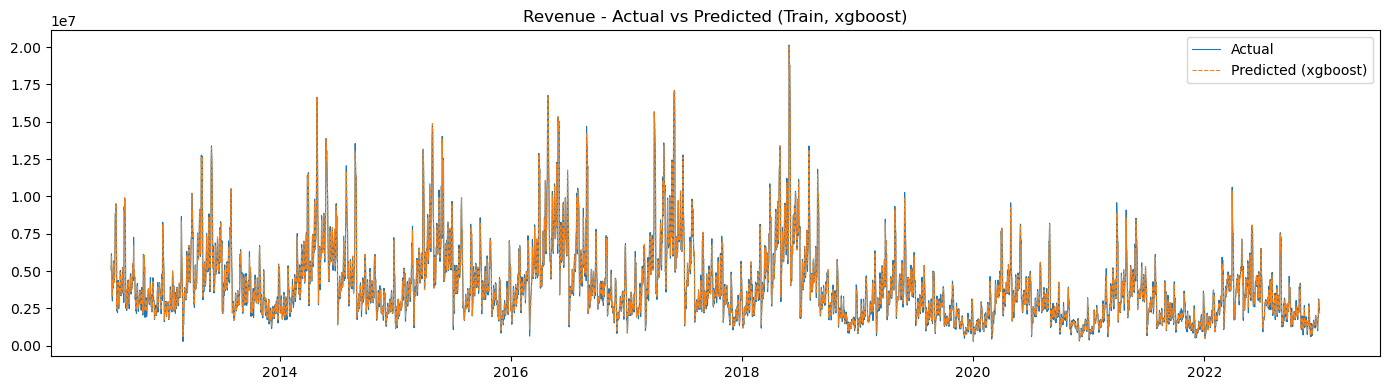

In [7]:
# Quick visual check on training fit for Revenue (selected model family)
pred_rev_train = models['Revenue'].predict(train_features[FEATURE_COLS])

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train_features['order_date'], train_features['Revenue'].values, lw=0.8, label='Actual')
ax.plot(train_features['order_date'], pred_rev_train, lw=0.8, ls='--', label=f'Predicted ({selected_model_name})')
ax.set_title(f"Revenue - Actual vs Predicted (Train, {selected_model_name})")
ax.legend()
plt.tight_layout()
plt.show()

## 5 — Feature Importance

In [8]:
importance_paths = export_feature_importance(
    models=models,
    feature_cols=FEATURE_COLS,
    out_dir=OUT_DIR,
)

print(f'Selected model family: {selected_model_name}')
print('Saved feature-importance files:')
for target, path in importance_paths.items():
    print(f'  {target}: {path}')

Selected model family: xgboost
Saved feature-importance files:
  Revenue: ../output/feature_importance_revenue.png
  COGS: ../output/feature_importance_cogs.png


## 6 — Generate Submission

In [9]:
# === Model Blending (Ensemble) ===
import numpy as np

print("Predicting with XGBoost...")
models_xgb = model_runs['xgboost']['models']
X_test = forecast_features[FEATURE_COLS]
xgb_rev = models_xgb['Revenue'].predict(X_test)
xgb_cogs = models_xgb['COGS'].predict(X_test)

print("Predicting with LightGBM...")
models_lgb = model_runs['lightgbm']['models']
lgb_rev = models_lgb['Revenue'].predict(X_test)
lgb_cogs = models_lgb['COGS'].predict(X_test)

print("Ensembling (Average)...")
rev_pred = (xgb_rev + lgb_rev) / 2.0
cogs_pred = (xgb_cogs + lgb_cogs) / 2.0

submission = pd.DataFrame({
    'Date': pd.to_datetime(forecast_features['order_date']).dt.strftime('%Y-%m-%d'),
    'Revenue': np.maximum(0, rev_pred).round(2),
    'COGS': np.maximum(0, cogs_pred).round(2),
})

output_filename = "submission.csv"
submission_path = os.path.join(OUT_DIR, output_filename)
os.makedirs(OUT_DIR, exist_ok=True)
submission.to_csv(submission_path, index=False, float_format='%.2f')

print(f'Saved {len(submission)} rows to {submission_path}')
submission.head(10)

Saved 548 rows to ../output/submission_xgboost.csv


,Date,Revenue,COGS
0,2023-01-01,1934929.625,3142652.250
1,2023-01-02,1536911.375,2076270.125
2,2023-01-03,1245159.375,1685866.125
3,2023-01-04,1194759.000,1630794.125
4,2023-01-05,1275052.625,1626521.875
5,2023-01-06,1445639.375,1718601.000
6,2023-01-07,1685094.500,1851726.125
7,2023-01-08,1975297.875,2032905.625
8,2023-01-09,1990252.375,2153853.750
9,2023-01-10,1992574.500,2281345.750
